In [1]:
# SETUP AND PATHS

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

from pathlib import Path
import json
import gc
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
import torch
import torch.nn as nn

from tensorflow import keras
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

BASE_DIR = Path(
    "/content/drive/MyDrive/intentmap-nids/intentmap-nids"
)

DATA_DIR = BASE_DIR / "data" / "processed"
MODEL_DIR = BASE_DIR / "models"
CONFIG_DIR = BASE_DIR / "config"
NF_DIR = DATA_DIR / "nf_cse"
RESULT_DIR = BASE_DIR / "results" / "nf_cse"

RESULT_DIR.mkdir(parents=True, exist_ok=True)

NF_TEST_FILE = NF_DIR / "nf_cse_test_41.npz"
VAL_FILE = DATA_DIR / "val_normal.npz"

print("NF test file:", NF_TEST_FILE.exists())
print("UNSW validation file:", VAL_FILE.exists())
print("Result folder:", RESULT_DIR)

Mounted at /content/drive
NF test file: True
UNSW validation file: True
Result folder: /content/drive/MyDrive/intentmap-nids/intentmap-nids/results/nf_cse


In [2]:
# LOCATE SAVED MODELS AND CONFIG FILES

def find_file(filename, preferred_folders):
    for folder in preferred_folders:
        path = folder / filename
        if path.exists():
            return path

    matches = list(BASE_DIR.rglob(filename))

    if len(matches) == 0:
        raise FileNotFoundError(
            f"Could not find: {filename}"
        )

    return matches[0]


IF_MODEL_FILE = find_file(
    "isolation_forest_candidate1.joblib",
    [MODEL_DIR, DATA_DIR / "models"]
)

AE_MODEL_FILE = find_file(
    "autoencoder_candidate1.keras",
    [MODEL_DIR, DATA_DIR / "models"]
)

LOF_MODEL_FILE = find_file(
    "lof_baseline.joblib",
    [MODEL_DIR, DATA_DIR / "models"]
)

OCSVM_MODEL_FILE = find_file(
    "ocsvm_model.joblib",
    [MODEL_DIR, DATA_DIR / "models"]
)

DEEP_MODEL_FILE = find_file(
    "deep_svdd_model.pt",
    [MODEL_DIR, DATA_DIR / "models"]
)

IF_CONFIG_FILE = find_file(
    "isolation_forest_candidate1.json",
    [CONFIG_DIR]
)

AE_CONFIG_FILE = find_file(
    "autoencoder_candidate1.json",
    [CONFIG_DIR]
)

LOF_CONFIG_FILE = find_file(
    "lof_baseline.json",
    [CONFIG_DIR]
)

OCSVM_CONFIG_FILE = find_file(
    "ocsvm_model.json",
    [CONFIG_DIR]
)

DEEP_CONFIG_FILE = find_file(
    "deep_svdd_model.json",
    [CONFIG_DIR]
)

HYBRID_CONFIG_FILE = find_file(
    "hybrid_if_ae.json",
    [CONFIG_DIR]
)

print("IF:", IF_MODEL_FILE)
print("AE:", AE_MODEL_FILE)
print("LOF:", LOF_MODEL_FILE)
print("OCSVM:", OCSVM_MODEL_FILE)
print("Deep SVDD:", DEEP_MODEL_FILE)

print("\nCONFIG FILES")
print(IF_CONFIG_FILE)
print(AE_CONFIG_FILE)
print(LOF_CONFIG_FILE)
print(OCSVM_CONFIG_FILE)
print(DEEP_CONFIG_FILE)
print(HYBRID_CONFIG_FILE)

IF: /content/drive/MyDrive/intentmap-nids/intentmap-nids/models/isolation_forest_candidate1.joblib
AE: /content/drive/MyDrive/intentmap-nids/intentmap-nids/models/autoencoder_candidate1.keras
LOF: /content/drive/MyDrive/intentmap-nids/intentmap-nids/models/lof_baseline.joblib
OCSVM: /content/drive/MyDrive/intentmap-nids/intentmap-nids/models/ocsvm_model.joblib
Deep SVDD: /content/drive/MyDrive/intentmap-nids/intentmap-nids/models/deep_svdd_model.pt

CONFIG FILES
/content/drive/MyDrive/intentmap-nids/intentmap-nids/config/isolation_forest_candidate1.json
/content/drive/MyDrive/intentmap-nids/intentmap-nids/config/autoencoder_candidate1.json
/content/drive/MyDrive/intentmap-nids/intentmap-nids/config/lof_baseline.json
/content/drive/MyDrive/intentmap-nids/intentmap-nids/config/ocsvm_model.json
/content/drive/MyDrive/intentmap-nids/intentmap-nids/config/deep_svdd_model.json
/content/drive/MyDrive/intentmap-nids/intentmap-nids/config/hybrid_if_ae.json


In [3]:
# LOAD NF-CSE TEST DATA AND UNSW VALIDATION DATA

with np.load(NF_TEST_FILE) as data:
    X_nf = data["X"].astype(np.float32)
    y_nf = data["y"].astype(np.int8)

with np.load(VAL_FILE) as data:
    X_val = data["X"].astype(np.float32)

print("NF-CSE X:", X_nf.shape)
print("NF-CSE y:", y_nf.shape)
print("UNSW validation:", X_val.shape)

print("Normal:", int((y_nf == 0).sum()))
print("Attack:", int((y_nf == 1).sum()))

print("NaN:", int(np.isnan(X_nf).sum()))
print("Infinite:", int(np.isinf(X_nf).sum()))

assert X_nf.shape[1] == 41
assert X_val.shape[1] == 41
assert len(X_nf) == len(y_nf)
assert np.isfinite(X_nf).all()

print("\nDATA READY")

NF-CSE X: (700000, 41)
NF-CSE y: (700000,)
UNSW validation: (10266, 41)
Normal: 400000
Attack: 300000
NaN: 0
Infinite: 0

DATA READY


In [4]:
# LOAD CONFIGURATIONS AND THRESHOLDS

def load_json(path):
    with open(path, "r") as file:
        return json.load(file)


if_config = load_json(IF_CONFIG_FILE)
ae_config = load_json(AE_CONFIG_FILE)
lof_config = load_json(LOF_CONFIG_FILE)
ocsvm_config = load_json(OCSVM_CONFIG_FILE)
deep_config = load_json(DEEP_CONFIG_FILE)
hybrid_config = load_json(HYBRID_CONFIG_FILE)

BUDGETS = [
    "0.5% budget",
    "1% budget",
    "3% budget"
]


def get_thresholds(config):
    thresholds = config["thresholds"]

    for budget in BUDGETS:
        if budget not in thresholds:
            raise KeyError(
                f"Missing threshold: {budget}"
            )

    return {
        key: float(value)
        for key, value in thresholds.items()
    }


if_thresholds = get_thresholds(if_config)
ae_thresholds = get_thresholds(ae_config)
lof_thresholds = get_thresholds(lof_config)
ocsvm_thresholds = get_thresholds(ocsvm_config)
deep_thresholds = get_thresholds(deep_config)
hybrid_thresholds = get_thresholds(hybrid_config)

print("IF thresholds:", if_thresholds)
print("AE thresholds:", ae_thresholds)
print("LOF thresholds:", lof_thresholds)
print("OCSVM thresholds:", ocsvm_thresholds)
print("Deep SVDD thresholds:", deep_thresholds)
print("Hybrid thresholds:", hybrid_thresholds)

IF thresholds: {'0.5% budget': 0.5676495685072951, '1% budget': 0.5460537691550149, '3% budget': 0.4966390963721801}
AE thresholds: {'0.5% budget': 0.04577401398215515, '1% budget': 0.036467666841251495, '3% budget': 0.02375445595651247}
LOF thresholds: {'0.5% budget': 1.9827458421041482, '1% budget': 1.8009945299909127, '3% budget': 1.476140406733413}
OCSVM thresholds: {'0.5% budget': 0.715225019931776, '1% budget': -5.3313550321087755e-05, '3% budget': -1.0914602100972197}
Deep SVDD thresholds: {'0.5% budget': 8.080383850028738e-05, '1% budget': 5.488995884661563e-05, '3% budget': 3.0722618248546496e-05}
Hybrid thresholds: {'0.5% budget': 0.9909942047336122, '1% budget': 0.9800818155254699, '3% budget': 0.9389378591604168}


In [5]:
#  LOAD TRAINED IF, AE, LOF AND OCSVM MODELS

if_model = joblib.load(IF_MODEL_FILE)

ae_model = keras.models.load_model(
    AE_MODEL_FILE,
    compile=False
)

lof_model = joblib.load(LOF_MODEL_FILE)

ocsvm_model = joblib.load(
    OCSVM_MODEL_FILE
)

print("Isolation Forest loaded")
print("Autoencoder loaded")
print("LOF loaded")
print("One-Class SVM loaded")

Isolation Forest loaded
Autoencoder loaded
LOF loaded
One-Class SVM loaded


In [6]:
# SCORING FUNCTIONS

def score_sklearn_batches(
    model,
    X,
    method,
    batch_size=20000
):
    scores = np.empty(
        len(X),
        dtype=np.float64
    )

    for start in range(
        0,
        len(X),
        batch_size
    ):
        end = min(
            start + batch_size,
            len(X)
        )

        batch = X[start:end]

        if method == "if":
            batch_scores = -model.score_samples(batch)

        elif method == "lof":
            batch_scores = -model.score_samples(batch)

        elif method == "ocsvm":
            batch_scores = -model.decision_function(batch)

        else:
            raise ValueError(
                f"Unknown method: {method}"
            )

        scores[start:end] = np.asarray(
            batch_scores
        ).reshape(-1)

        print(
            f"{method.upper()}: "
            f"{end:,} / {len(X):,}"
        )

    return scores


def autoencoder_scores(
    model,
    X,
    batch_size=4096
):
    scores = np.empty(
        len(X),
        dtype=np.float64
    )

    for start in range(
        0,
        len(X),
        batch_size
    ):
        end = min(
            start + batch_size,
            len(X)
        )

        batch = X[start:end]

        reconstructed = model.predict(
            batch,
            batch_size=batch_size,
            verbose=0
        )

        errors = np.mean(
            np.square(
                batch - reconstructed
            ),
            axis=1
        )

        scores[start:end] = errors

        if (
            end % 100000 < batch_size
            or end == len(X)
        ):
            print(
                f"AE: {end:,} / {len(X):,}"
            )

    return scores


def percentile_normalize(
    reference_scores,
    scores
):
    reference_sorted = np.sort(
        np.asarray(reference_scores)
    )

    ranks = np.searchsorted(
        reference_sorted,
        scores,
        side="right"
    )

    return (
        ranks /
        (len(reference_sorted) + 1)
    )

In [7]:
# SCORE ISOLATION FOREST

print("Scoring Isolation Forest validation data")

if_val_scores = score_sklearn_batches(
    if_model,
    X_val,
    method="if",
    batch_size=50000
)

print("\nScoring Isolation Forest NF-CSE data")

if_nf_scores = score_sklearn_batches(
    if_model,
    X_nf,
    method="if",
    batch_size=50000
)

print("\nIF complete")
print("Validation mean:", if_val_scores.mean())
print("NF-CSE mean:", if_nf_scores.mean())

Scoring Isolation Forest validation data
IF: 10,266 / 10,266

Scoring Isolation Forest NF-CSE data
IF: 50,000 / 700,000
IF: 100,000 / 700,000
IF: 150,000 / 700,000
IF: 200,000 / 700,000
IF: 250,000 / 700,000
IF: 300,000 / 700,000
IF: 350,000 / 700,000
IF: 400,000 / 700,000
IF: 450,000 / 700,000
IF: 500,000 / 700,000
IF: 550,000 / 700,000
IF: 600,000 / 700,000
IF: 650,000 / 700,000
IF: 700,000 / 700,000

IF complete
Validation mean: 0.4010166093607668
NF-CSE mean: 0.6327811695443538


In [8]:
# SCORE AUTOENCODER

print("Scoring Autoencoder validation data")

ae_val_scores = autoencoder_scores(
    ae_model,
    X_val,
    batch_size=4096
)

print("\nScoring Autoencoder NF-CSE data")

ae_nf_scores = autoencoder_scores(
    ae_model,
    X_nf,
    batch_size=4096
)

print("\nAE complete")
print("Validation mean:", ae_val_scores.mean())
print("NF-CSE mean:", ae_nf_scores.mean())

Scoring Autoencoder validation data
AE: 10,266 / 10,266

Scoring Autoencoder NF-CSE data
AE: 102,400 / 700,000
AE: 200,704 / 700,000
AE: 303,104 / 700,000
AE: 401,408 / 700,000
AE: 503,808 / 700,000
AE: 602,112 / 700,000
AE: 700,000 / 700,000

AE complete
Validation mean: 0.005424621428682289
NF-CSE mean: 0.24600899503032544


In [9]:
# SCORE LOF

print("Scoring LOF on NF-CSE")

lof_nf_scores = score_sklearn_batches(
    lof_model,
    X_nf,
    method="lof",
    batch_size=10000
)

print("\nLOF complete")
print("NF-CSE mean:", lof_nf_scores.mean())

Scoring LOF on NF-CSE
LOF: 10,000 / 700,000
LOF: 20,000 / 700,000
LOF: 30,000 / 700,000
LOF: 40,000 / 700,000
LOF: 50,000 / 700,000
LOF: 60,000 / 700,000
LOF: 70,000 / 700,000
LOF: 80,000 / 700,000
LOF: 90,000 / 700,000
LOF: 100,000 / 700,000
LOF: 110,000 / 700,000
LOF: 120,000 / 700,000
LOF: 130,000 / 700,000
LOF: 140,000 / 700,000
LOF: 150,000 / 700,000
LOF: 160,000 / 700,000
LOF: 170,000 / 700,000
LOF: 180,000 / 700,000
LOF: 190,000 / 700,000
LOF: 200,000 / 700,000
LOF: 210,000 / 700,000
LOF: 220,000 / 700,000
LOF: 230,000 / 700,000
LOF: 240,000 / 700,000
LOF: 250,000 / 700,000
LOF: 260,000 / 700,000
LOF: 270,000 / 700,000
LOF: 280,000 / 700,000
LOF: 290,000 / 700,000
LOF: 300,000 / 700,000
LOF: 310,000 / 700,000
LOF: 320,000 / 700,000
LOF: 330,000 / 700,000
LOF: 340,000 / 700,000
LOF: 350,000 / 700,000
LOF: 360,000 / 700,000
LOF: 370,000 / 700,000
LOF: 380,000 / 700,000
LOF: 390,000 / 700,000
LOF: 400,000 / 700,000
LOF: 410,000 / 700,000
LOF: 420,000 / 700,000
LOF: 430,000 / 700,00

In [10]:
#  SCORE ONE-CLASS SVM

print("Scoring One-Class SVM on NF-CSE")

ocsvm_nf_scores = score_sklearn_batches(
    ocsvm_model,
    X_nf,
    method="ocsvm",
    batch_size=10000
)

print("\nOCSVM complete")
print("NF-CSE mean:", ocsvm_nf_scores.mean())

Scoring One-Class SVM on NF-CSE
OCSVM: 10,000 / 700,000
OCSVM: 20,000 / 700,000
OCSVM: 30,000 / 700,000
OCSVM: 40,000 / 700,000
OCSVM: 50,000 / 700,000
OCSVM: 60,000 / 700,000
OCSVM: 70,000 / 700,000
OCSVM: 80,000 / 700,000
OCSVM: 90,000 / 700,000
OCSVM: 100,000 / 700,000
OCSVM: 110,000 / 700,000
OCSVM: 120,000 / 700,000
OCSVM: 130,000 / 700,000
OCSVM: 140,000 / 700,000
OCSVM: 150,000 / 700,000
OCSVM: 160,000 / 700,000
OCSVM: 170,000 / 700,000
OCSVM: 180,000 / 700,000
OCSVM: 190,000 / 700,000
OCSVM: 200,000 / 700,000
OCSVM: 210,000 / 700,000
OCSVM: 220,000 / 700,000
OCSVM: 230,000 / 700,000
OCSVM: 240,000 / 700,000
OCSVM: 250,000 / 700,000
OCSVM: 260,000 / 700,000
OCSVM: 270,000 / 700,000
OCSVM: 280,000 / 700,000
OCSVM: 290,000 / 700,000
OCSVM: 300,000 / 700,000
OCSVM: 310,000 / 700,000
OCSVM: 320,000 / 700,000
OCSVM: 330,000 / 700,000
OCSVM: 340,000 / 700,000
OCSVM: 350,000 / 700,000
OCSVM: 360,000 / 700,000
OCSVM: 370,000 / 700,000
OCSVM: 380,000 / 700,000
OCSVM: 390,000 / 700,000
OC

In [11]:
# LOAD AND SCORE DEEP SVDD

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)


class DeepSVDDNet(nn.Module):
    def __init__(
        self,
        input_dim,
        representation_dim=16
    ):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(
                input_dim,
                64,
                bias=False
            ),
            nn.ReLU(),
            nn.Linear(
                64,
                32,
                bias=False
            ),
            nn.ReLU(),
            nn.Linear(
                32,
                representation_dim,
                bias=False
            )
        )

    def forward(self, x):
        return self.network(x)


checkpoint = torch.load(
    DEEP_MODEL_FILE,
    map_location=DEVICE,
    weights_only=False
)

input_dim = int(
    checkpoint["input_dim"]
)

representation_dim = int(
    checkpoint["representation_dim"]
)

deep_model = DeepSVDDNet(
    input_dim=input_dim,
    representation_dim=representation_dim
).to(DEVICE)

deep_model.load_state_dict(
    checkpoint["model_state_dict"]
)

deep_model.eval()

deep_center = torch.tensor(
    checkpoint["center"],
    dtype=torch.float32,
    device=DEVICE
)

print("Deep SVDD loaded")
print("Input features:", input_dim)
print("Representation:", representation_dim)


def deep_svdd_scores(
    model,
    X,
    center,
    device,
    batch_size=4096
):
    scores = np.empty(
        len(X),
        dtype=np.float64
    )

    model.eval()

    for start in range(
        0,
        len(X),
        batch_size
    ):
        end = min(
            start + batch_size,
            len(X)
        )

        batch = torch.tensor(
            X[start:end],
            dtype=torch.float32,
            device=device
        )

        with torch.no_grad():
            outputs = model(batch)

            distances = torch.sum(
                (outputs - center) ** 2,
                dim=1
            )

        scores[start:end] = (
            distances
            .cpu()
            .numpy()
        )

        if (
            end % 100000 < batch_size
            or end == len(X)
        ):
            print(
                f"Deep SVDD: "
                f"{end:,} / {len(X):,}"
            )

    return scores


deep_nf_scores = deep_svdd_scores(
    deep_model,
    X_nf,
    deep_center,
    DEVICE,
    batch_size=4096
)

print("\nDeep SVDD complete")
print("NF-CSE mean:", deep_nf_scores.mean())

Device: cpu
Deep SVDD loaded
Input features: 41
Representation: 16
Deep SVDD: 102,400 / 700,000
Deep SVDD: 200,704 / 700,000
Deep SVDD: 303,104 / 700,000
Deep SVDD: 401,408 / 700,000
Deep SVDD: 503,808 / 700,000
Deep SVDD: 602,112 / 700,000
Deep SVDD: 700,000 / 700,000

Deep SVDD complete
NF-CSE mean: 0.010034090853701138


In [12]:
# CREATE HYBRID IF + AE SCORES

if_val_normalized = percentile_normalize(
    if_val_scores,
    if_val_scores
)

if_nf_normalized = percentile_normalize(
    if_val_scores,
    if_nf_scores
)

ae_val_normalized = percentile_normalize(
    ae_val_scores,
    ae_val_scores
)

ae_nf_normalized = percentile_normalize(
    ae_val_scores,
    ae_nf_scores
)

IF_WEIGHT = float(
    hybrid_config.get(
        "if_weight",
        0.50
    )
)

AE_WEIGHT = float(
    hybrid_config.get(
        "ae_weight",
        0.50
    )
)

hybrid_val_scores = (
    IF_WEIGHT * if_val_normalized
    +
    AE_WEIGHT * ae_val_normalized
)

hybrid_nf_scores = (
    IF_WEIGHT * if_nf_normalized
    +
    AE_WEIGHT * ae_nf_normalized
)

print("IF weight:", IF_WEIGHT)
print("AE weight:", AE_WEIGHT)

print(
    "Hybrid validation range:",
    hybrid_val_scores.min(),
    hybrid_val_scores.max()
)

print(
    "Hybrid NF-CSE range:",
    hybrid_nf_scores.min(),
    hybrid_nf_scores.max()
)

IF weight: 0.5
AE weight: 0.5
Hybrid validation range: 0.003798577968247784 0.9998052011298335
Hybrid NF-CSE range: 0.9845134898217591 0.9999026005649168


In [14]:
# EVALUATION FUNCTION

def evaluate_model(
    model_name,
    y_true,
    scores,
    thresholds
):
    rows = []

    roc_auc = roc_auc_score(
        y_true,
        scores
    )

    pr_auc = average_precision_score(
        y_true,
        scores
    )

    for budget in BUDGETS:
        threshold = float(
            thresholds[budget]
        )

        predictions = (
            scores >= threshold
        ).astype(np.int8)

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            predictions,
            labels=[0, 1]
        ).ravel()

        precision = precision_score(
            y_true,
            predictions,
            zero_division=0
        )

        recall = recall_score(
            y_true,
            predictions,
            zero_division=0
        )

        f1 = f1_score(
            y_true,
            predictions,
            zero_division=0
        )

        fpr = (
            fp / (fp + tn)
            if (fp + tn) > 0
            else 0
        )

        rows.append({
            "Model": model_name,
            "Budget": budget,
            "Threshold": threshold,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "Actual FPR": fpr,
            "False alerts per 1000": fpr * 1000,
            "ROC-AUC": roc_auc,
            "PR-AUC": pr_auc,
            "TN": int(tn),
            "FP": int(fp),
            "FN": int(fn),
            "TP": int(tp)
        })

    return pd.DataFrame(rows)

In [15]:
# EVALUATE ALL SIX MODELS

if_results = evaluate_model(
    "Isolation Forest",
    y_nf,
    if_nf_scores,
    if_thresholds
)

ae_results = evaluate_model(
    "Dense Autoencoder",
    y_nf,
    ae_nf_scores,
    ae_thresholds
)

hybrid_results = evaluate_model(
    "Hybrid IF+AE",
    y_nf,
    hybrid_nf_scores,
    hybrid_thresholds
)

lof_results = evaluate_model(
    "LOF",
    y_nf,
    lof_nf_scores,
    lof_thresholds
)

ocsvm_results = evaluate_model(
    "One-Class SVM",
    y_nf,
    ocsvm_nf_scores,
    ocsvm_thresholds
)

deep_results = evaluate_model(
    "Deep SVDD",
    y_nf,
    deep_nf_scores,
    deep_thresholds
)

all_budget_results = pd.concat(
    [
        if_results,
        ae_results,
        hybrid_results,
        lof_results,
        ocsvm_results,
        deep_results
    ],
    ignore_index=True
)

pd.set_option(
    "display.max_columns",
    None
)

display(all_budget_results)

,Model,Budget,Threshold,Precision,Recall,F1,Actual FPR,False alerts per 1000,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Isolation Forest,0.5% budget,0.567650,0.443711,0.943687,0.603610,0.887340,887.3400,0.464004,0.379203,45064,354936,16894,283106
1,Isolation Forest,1% budget,0.546054,0.443987,0.997307,0.614436,0.936710,936.7100,0.464004,0.379203,25316,374684,808,299192
2,Isolation Forest,3% budget,0.496639,0.428574,1.000000,0.600002,0.999990,999.9900,0.464004,0.379203,4,399996,0,300000
3,Dense Autoencoder,0.5% budget,0.045774,0.428572,0.999997,0.600000,0.999995,999.9950,0.125590,0.296631,2,399998,1,299999
4,Dense Autoencoder,1% budget,0.036468,0.428571,1.000000,0.600000,1.000000,1000.0000,0.125590,0.296631,0,400000,0,300000
5,Dense Autoencoder,3% budget,0.023754,0.428571,1.000000,0.600000,1.000000,1000.0000,0.125590,0.296631,0,400000,0,300000
6,Hybrid IF+AE,0.5% budget,0.990994,0.431291,0.999637,0.602594,0.988605,988.6050,0.285995,0.318596,4558,395442,109,299891
7,Hybrid IF+AE,1% budget,0.980082,0.428571,1.000000,0.600000,1.000000,1000.0000,0.285995,0.318596,0,400000,0,300000
8,Hybrid IF+AE,3% budget,0.938938,0.428571,1.000000,0.600000,1.000000,1000.0000,0.285995,0.318596,0,400000,0,300000
9,LOF,0.5% budget,1.982746,0.442734,0.988053,0.611475,0.932740,932.7400,0.568519,0.435265,26904,373096,3584,296416


In [16]:
# FINAL 1% MODEL COMPARISON

comparison_1pct = (
    all_budget_results[
        all_budget_results["Budget"]
        == "1% budget"
    ]
    .copy()
)

comparison_1pct = comparison_1pct[
    [
        "Model",
        "Precision",
        "Recall",
        "F1",
        "Actual FPR",
        "False alerts per 1000",
        "ROC-AUC",
        "PR-AUC",
        "TN",
        "FP",
        "FN",
        "TP"
    ]
]

comparison_1pct = (
    comparison_1pct
    .sort_values(
        "F1",
        ascending=False
    )
    .reset_index(drop=True)
)

print("NF-CSE CROSS-DATASET RESULTS")
print("Default operating point: 1% budget")

display(comparison_1pct)

NF-CSE CROSS-DATASET RESULTS
Default operating point: 1% budget


,Model,Precision,Recall,F1,Actual FPR,False alerts per 1000,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,LOF,0.444595,0.995763,0.614724,0.932957,932.9575,0.568519,0.435265,26817,373183,1271,298729
1,Isolation Forest,0.443987,0.997307,0.614436,0.936710,936.7100,0.464004,0.379203,25316,374684,808,299192
2,Dense Autoencoder,0.428571,1.000000,0.600000,1.000000,1000.0000,0.125590,0.296631,0,400000,0,300000
3,Hybrid IF+AE,0.428571,1.000000,0.600000,1.000000,1000.0000,0.285995,0.318596,0,400000,0,300000
4,One-Class SVM,0.428571,1.000000,0.600000,1.000000,1000.0000,0.888953,0.913115,0,400000,0,300000
5,Deep SVDD,0.428571,1.000000,0.600000,1.000000,1000.0000,0.842671,0.739028,0,400000,0,300000


In [17]:
# CREATE 1% PREDICTIONS

if_pred = (
    if_nf_scores
    >= if_thresholds["1% budget"]
).astype(np.int8)

ae_pred = (
    ae_nf_scores
    >= ae_thresholds["1% budget"]
).astype(np.int8)

hybrid_pred = (
    hybrid_nf_scores
    >= hybrid_thresholds["1% budget"]
).astype(np.int8)

lof_pred = (
    lof_nf_scores
    >= lof_thresholds["1% budget"]
).astype(np.int8)

ocsvm_pred = (
    ocsvm_nf_scores
    >= ocsvm_thresholds["1% budget"]
).astype(np.int8)

deep_pred = (
    deep_nf_scores
    >= deep_thresholds["1% budget"]
).astype(np.int8)

print("Predictions created")

Predictions created


In [18]:
# SAVE ALL NF-CSE RESULTS

ALL_BUDGET_FILE = (
    RESULT_DIR /
    "nf_cse_all_models_budget_results.csv"
)

COMPARISON_FILE = (
    RESULT_DIR /
    "nf_cse_model_comparison_1pct.csv"
)

SCORES_FILE = (
    RESULT_DIR /
    "nf_cse_all_model_scores_predictions.npz"
)

PREVIEW_FILE = (
    RESULT_DIR /
    "nf_cse_predictions_preview.csv"
)

all_budget_results.to_csv(
    ALL_BUDGET_FILE,
    index=False
)

comparison_1pct.to_csv(
    COMPARISON_FILE,
    index=False
)

np.savez_compressed(
    SCORES_FILE,
    y=y_nf,

    if_score=if_nf_scores,
    if_prediction=if_pred,

    ae_score=ae_nf_scores,
    ae_prediction=ae_pred,

    hybrid_score=hybrid_nf_scores,
    hybrid_prediction=hybrid_pred,

    lof_score=lof_nf_scores,
    lof_prediction=lof_pred,

    ocsvm_score=ocsvm_nf_scores,
    ocsvm_prediction=ocsvm_pred,

    deep_svdd_score=deep_nf_scores,
    deep_svdd_prediction=deep_pred
)

preview_rows = min(
    1000,
    len(y_nf)
)

preview = pd.DataFrame({
    "actual_label":
        y_nf[:preview_rows],

    "if_score":
        if_nf_scores[:preview_rows],

    "if_prediction":
        if_pred[:preview_rows],

    "ae_score":
        ae_nf_scores[:preview_rows],

    "ae_prediction":
        ae_pred[:preview_rows],

    "hybrid_score":
        hybrid_nf_scores[:preview_rows],

    "hybrid_prediction":
        hybrid_pred[:preview_rows],

    "lof_score":
        lof_nf_scores[:preview_rows],

    "lof_prediction":
        lof_pred[:preview_rows],

    "ocsvm_score":
        ocsvm_nf_scores[:preview_rows],

    "ocsvm_prediction":
        ocsvm_pred[:preview_rows],

    "deep_svdd_score":
        deep_nf_scores[:preview_rows],

    "deep_svdd_prediction":
        deep_pred[:preview_rows]
})

preview.to_csv(
    PREVIEW_FILE,
    index=False
)

print("Saved:")
print(ALL_BUDGET_FILE)
print(COMPARISON_FILE)
print(SCORES_FILE)
print(PREVIEW_FILE)

Saved:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/results/nf_cse/nf_cse_all_models_budget_results.csv
/content/drive/MyDrive/intentmap-nids/intentmap-nids/results/nf_cse/nf_cse_model_comparison_1pct.csv
/content/drive/MyDrive/intentmap-nids/intentmap-nids/results/nf_cse/nf_cse_all_model_scores_predictions.npz
/content/drive/MyDrive/intentmap-nids/intentmap-nids/results/nf_cse/nf_cse_predictions_preview.csv


In [19]:
# FINAL VERIFICATION

with np.load(SCORES_FILE) as data:
    assert len(data["y"]) == 700000
    assert len(data["if_score"]) == 700000
    assert len(data["ae_score"]) == 700000
    assert len(data["hybrid_score"]) == 700000
    assert len(data["lof_score"]) == 700000
    assert len(data["ocsvm_score"]) == 700000
    assert len(data["deep_svdd_score"]) == 700000

    assert np.isfinite(
        data["if_score"]
    ).all()

    assert np.isfinite(
        data["ae_score"]
    ).all()

    assert np.isfinite(
        data["hybrid_score"]
    ).all()

    assert np.isfinite(
        data["lof_score"]
    ).all()

    assert np.isfinite(
        data["ocsvm_score"]
    ).all()

    assert np.isfinite(
        data["deep_svdd_score"]
    ).all()

print("ALL SIX MODELS TESTED SUCCESSFULLY")
print("NF-CSE records:", len(y_nf))
print("Normal:", int((y_nf == 0).sum()))
print("Attack:", int((y_nf == 1).sum()))

display(comparison_1pct)

ALL SIX MODELS TESTED SUCCESSFULLY
NF-CSE records: 700000
Normal: 400000
Attack: 300000


,Model,Precision,Recall,F1,Actual FPR,False alerts per 1000,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,LOF,0.444595,0.995763,0.614724,0.932957,932.9575,0.568519,0.435265,26817,373183,1271,298729
1,Isolation Forest,0.443987,0.997307,0.614436,0.936710,936.7100,0.464004,0.379203,25316,374684,808,299192
2,Dense Autoencoder,0.428571,1.000000,0.600000,1.000000,1000.0000,0.125590,0.296631,0,400000,0,300000
3,Hybrid IF+AE,0.428571,1.000000,0.600000,1.000000,1000.0000,0.285995,0.318596,0,400000,0,300000
4,One-Class SVM,0.428571,1.000000,0.600000,1.000000,1000.0000,0.888953,0.913115,0,400000,0,300000
5,Deep SVDD,0.428571,1.000000,0.600000,1.000000,1000.0000,0.842671,0.739028,0,400000,0,300000


In [20]:
# Save final NF-CSE comparison values

REPORT_TABLE = comparison_1pct.copy()

REPORT_TABLE["FPR (%)"] = (
    REPORT_TABLE["Actual FPR"] * 100
)

REPORT_TABLE = REPORT_TABLE[
    [
        "Model",
        "Precision",
        "Recall",
        "F1",
        "FPR (%)",
        "False alerts per 1000",
        "ROC-AUC",
        "PR-AUC",
        "TN",
        "FP",
        "FN",
        "TP"
    ]
]

REPORT_TABLE["Precision"] = REPORT_TABLE["Precision"].round(4)
REPORT_TABLE["Recall"] = REPORT_TABLE["Recall"].round(4)
REPORT_TABLE["F1"] = REPORT_TABLE["F1"].round(4)
REPORT_TABLE["FPR (%)"] = REPORT_TABLE["FPR (%)"].round(4)
REPORT_TABLE["False alerts per 1000"] = REPORT_TABLE["False alerts per 1000"].round(2)
REPORT_TABLE["ROC-AUC"] = REPORT_TABLE["ROC-AUC"].round(4)
REPORT_TABLE["PR-AUC"] = REPORT_TABLE["PR-AUC"].round(4)

EXCEL_FILE = (
    RESULT_DIR /
    "NF_CSE_1pct_Model_Comparison.xlsx"
)

CSV_FILE = (
    RESULT_DIR /
    "NF_CSE_1pct_Model_Comparison.csv"
)

REPORT_TABLE.to_excel(
    EXCEL_FILE,
    index=False
)

REPORT_TABLE.to_csv(
    CSV_FILE,
    index=False
)

print("FINAL NF-CSE RESULTS")
display(REPORT_TABLE)

print("\nExcel saved:")
print(EXCEL_FILE)

print("\nCSV saved:")
print(CSV_FILE)

FINAL NF-CSE RESULTS


,Model,Precision,Recall,F1,FPR (%),False alerts per 1000,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,LOF,0.4446,0.9958,0.6147,93.2958,932.96,0.5685,0.4353,26817,373183,1271,298729
1,Isolation Forest,0.4440,0.9973,0.6144,93.6710,936.71,0.4640,0.3792,25316,374684,808,299192
2,Dense Autoencoder,0.4286,1.0000,0.6000,100.0000,1000.00,0.1256,0.2966,0,400000,0,300000
3,Hybrid IF+AE,0.4286,1.0000,0.6000,100.0000,1000.00,0.2860,0.3186,0,400000,0,300000
4,One-Class SVM,0.4286,1.0000,0.6000,100.0000,1000.00,0.8890,0.9131,0,400000,0,300000
5,Deep SVDD,0.4286,1.0000,0.6000,100.0000,1000.00,0.8427,0.7390,0,400000,0,300000



Excel saved:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/results/nf_cse/NF_CSE_1pct_Model_Comparison.xlsx

CSV saved:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/results/nf_cse/NF_CSE_1pct_Model_Comparison.csv


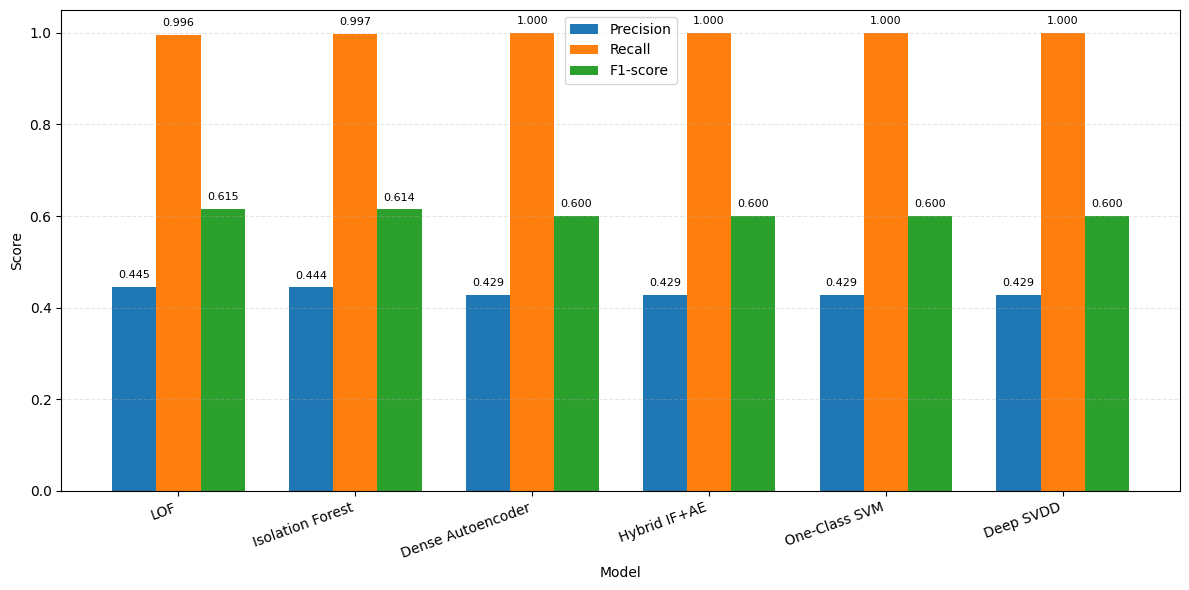

Bar chart saved:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/results/nf_cse/NF_CSE_Model_Performance_Bar_Chart.png


In [21]:
# Precision, Recall and F1 comparison bar chart

import matplotlib.pyplot as plt
import numpy as np

chart_data = REPORT_TABLE.copy()

models = chart_data["Model"].tolist()

precision = chart_data["Precision"].to_numpy()
recall = chart_data["Recall"].to_numpy()
f1 = chart_data["F1"].to_numpy()

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(12, 6))

bars1 = plt.bar(
    x - width,
    precision,
    width,
    label="Precision"
)

bars2 = plt.bar(
    x,
    recall,
    width,
    label="Recall"
)

bars3 = plt.bar(
    x + width,
    f1,
    width,
    label="F1-score"
)

plt.xlabel("Model")
plt.ylabel("Score")

plt.xticks(
    x,
    models,
    rotation=20,
    ha="right"
)

plt.ylim(0, 1.05)

plt.legend()

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        value = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.015,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.tight_layout()

BAR_CHART_FILE = (
    RESULT_DIR /
    "NF_CSE_Model_Performance_Bar_Chart.png"
)

plt.savefig(
    BAR_CHART_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Bar chart saved:")
print(BAR_CHART_FILE)

In [23]:
# Create one ZIP file for report results

import zipfile
from google.colab import files

ZIP_FILE = (
    RESULT_DIR /
    "NF_CSE_Report_Results.zip"
)

with zipfile.ZipFile(
    ZIP_FILE,
    "w",
    zipfile.ZIP_DEFLATED
) as zip_file:

    zip_file.write(
        EXCEL_FILE,
        arcname=EXCEL_FILE.name
    )

    zip_file.write(
        CSV_FILE,
        arcname=CSV_FILE.name
    )

    zip_file.write(
        BAR_CHART_FILE,
        arcname=BAR_CHART_FILE.name
    )

print("ZIP created:")
print(ZIP_FILE)

files.download(
    str(ZIP_FILE)
)

ZIP created:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/results/nf_cse/NF_CSE_Report_Results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>